##Imports




In [1]:
#pip install ydata-profiling

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier as rfc
from sklearn.feature_selection import mutual_info_classif
#from ydata_profiling import ProfileReport

##Initial Data Profiling


In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/ccyang8792/ccyang8792.github.io/main/CapStone/nfl_combine_clean.csv')

In [4]:
df.head()

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year
0,Darrell Adams,DE,Defense,Villanova,77.0,277.0,5.00,27.0,22.0,109.0,7.91,4.76,NaN,NaN,2006
1,Titus Adams,DT,Defense,Nebraska,75.0,306.0,5.07,30.5,15.0,103.0,7.49,4.54,New York Jets,7.0,2006
2,Jahmile Addae,S,Defense,West Virginia,70.0,214.0,4.70,38.5,NaN,122.0,NaN,NaN,NaN,NaN,2006
3,Joseph Addai,RB,Offense,LSU,71.0,214.0,4.40,38.5,18.0,125.0,7.09,4.47,Indianapolis Colts,1.0,2006
4,Victor Adeyanju,DE,Defense,Indiana,76.0,274.0,4.86,32.0,22.0,112.0,7.37,4.41,Los Angeles Rams,4.0,2006


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6702 entries, 0 to 6701
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Player      6702 non-null   object 
 1   Pos         6702 non-null   object 
 2   Off_Def     6702 non-null   object 
 3   School      6702 non-null   object 
 4   Ht          6673 non-null   float64
 5   Wt          6678 non-null   float64
 6   40yd        5934 non-null   float64
 7   Vertical    5198 non-null   float64
 8   Bench       4213 non-null   float64
 9   Broad Jump  5106 non-null   float64
 10  3Cone       3828 non-null   float64
 11  Shuttle     3974 non-null   float64
 12  Team        4292 non-null   object 
 13  Round       4292 non-null   float64
 14  Year        6702 non-null   int64  
dtypes: float64(9), int64(1), object(5)
memory usage: 785.5+ KB


In [6]:
df.describe()

,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Round,Year
count,6673.000000,6678.000000,5934.000000,5198.000000,4213.000000,5106.000000,3828.000000,3974.000000,4292.000000,6702.000000
mean,73.948299,241.924828,4.757405,32.924740,20.547591,115.627889,7.253511,4.416605,3.850652,2015.606834
std,2.612205,45.507048,0.301254,4.248127,6.372493,9.281336,0.402353,0.259255,1.925752,5.746173
min,64.000000,144.000000,4.210000,17.500000,2.000000,74.000000,6.280000,3.810000,1.000000,2006.000000
25%,73.000000,205.000000,4.520000,30.000000,16.000000,110.000000,6.960000,4.220000,2.000000,2011.000000
50%,74.000000,231.000000,4.670000,33.000000,20.000000,117.000000,7.160000,4.370000,4.000000,2016.000000
75%,76.000000,278.000000,4.950000,36.000000,25.000000,122.000000,7.500000,4.570000,5.000000,2021.000000
max,82.000000,384.000000,6.000000,46.500000,49.000000,147.000000,9.040000,5.560000,7.000000,2025.000000


In [7]:
df.shape

(6702, 15)

In [8]:
df.groupby('Pos').apply(lambda x: x.isna().sum())

/tmp/ipykernel_838/315016510.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Pos').apply(lambda x: x.isna().sum())


,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year
Pos,,,,,,,,,,,,,,,
C,0,0,0,0,0,0,22,40,58,42,55,51,64,64,0
CB,0,0,0,0,2,2,66,163,239,172,371,351,244,244,0
CB/WR,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0
DE,0,0,0,0,4,3,33,96,108,102,161,160,136,136,0
DT,0,0,0,0,1,0,50,97,138,115,175,165,124,124,0
EDGE,0,0,0,0,0,0,53,45,72,48,111,105,55,55,0
FB,0,0,0,0,0,0,2,11,11,11,18,18,34,34,0
ILB,0,0,0,0,0,0,11,42,36,39,82,74,69,69,0
K,0,0,0,0,1,0,45,88,84,87,89,89,63,63,0


In [9]:
df['Drafted'] = df['Round'].notna().astype(int)

###Y-Data Profile

> Add blockquote



In [10]:
#profile = ProfileReport(df, title='Profiling Report')
#profile

In [11]:
#profile.to_file('nfl_report.html')

Profile Report


https://ccyang8792.github.io/CapStone/nfl_report.html

In [12]:
df.head()

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year,Drafted
0,Darrell Adams,DE,Defense,Villanova,77.0,277.0,5.00,27.0,22.0,109.0,7.91,4.76,NaN,NaN,2006,0
1,Titus Adams,DT,Defense,Nebraska,75.0,306.0,5.07,30.5,15.0,103.0,7.49,4.54,New York Jets,7.0,2006,1
2,Jahmile Addae,S,Defense,West Virginia,70.0,214.0,4.70,38.5,NaN,122.0,NaN,NaN,NaN,NaN,2006,0
3,Joseph Addai,RB,Offense,LSU,71.0,214.0,4.40,38.5,18.0,125.0,7.09,4.47,Indianapolis Colts,1.0,2006,1
4,Victor Adeyanju,DE,Defense,Indiana,76.0,274.0,4.86,32.0,22.0,112.0,7.37,4.41,Los Angeles Rams,4.0,2006,1


In [13]:
#sns.pairplot(df)

###Box Plots and Histograms

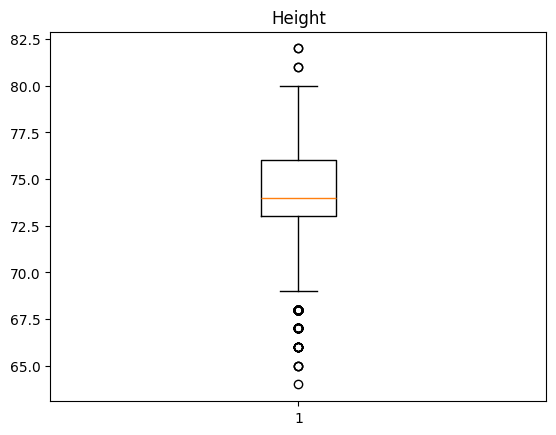

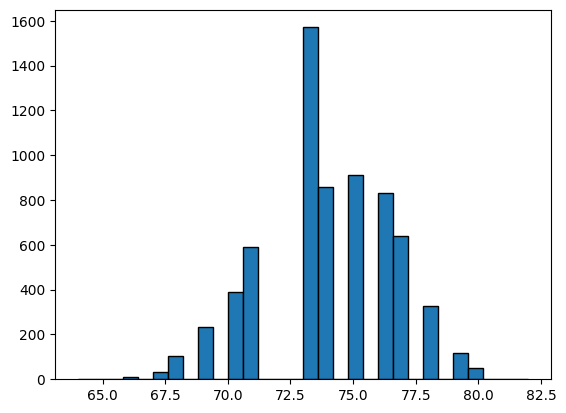

In [14]:
plt.boxplot(df['Ht'].dropna())
plt.title('Height')
plt.show()
plt.hist(df['Ht'].dropna(), bins=30, edgecolor='black');

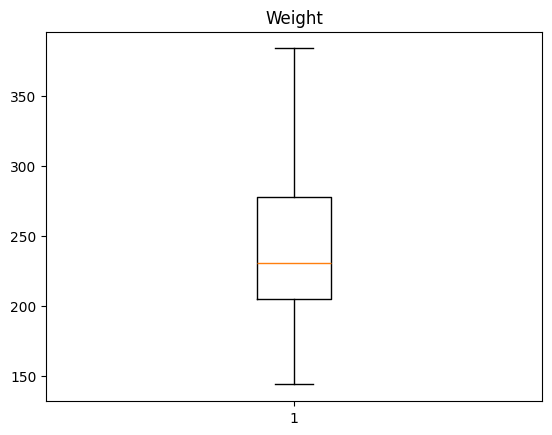

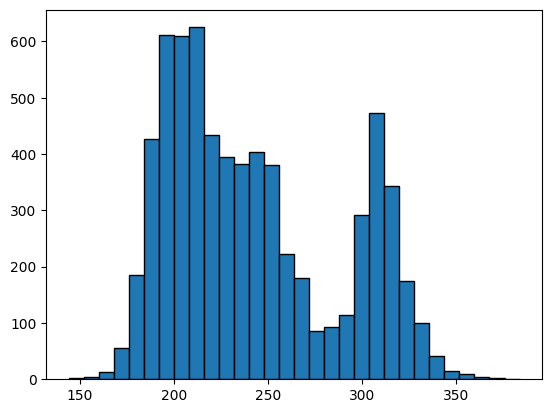

In [15]:
plt.boxplot(df['Wt'].dropna())
plt.title('Weight')
plt.show()
plt.hist(df['Wt'].dropna(), bins=30, edgecolor='black');

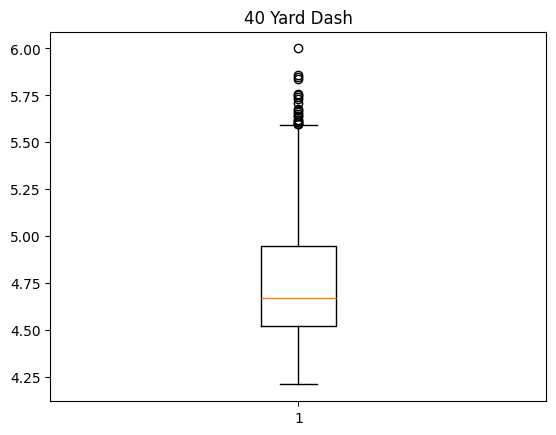

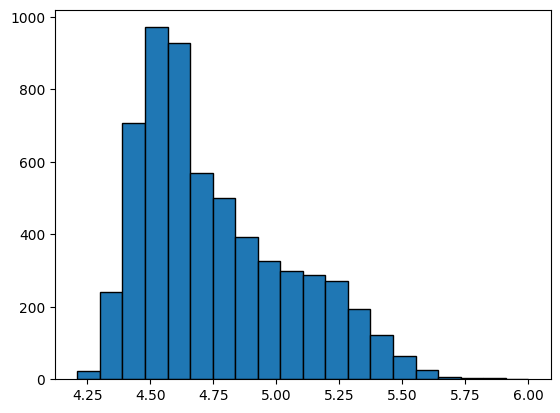

In [16]:
plt.boxplot(df['40yd'].dropna())
plt.title('40 Yard Dash')
plt.show()
plt.hist(df['40yd'].dropna(), bins=20, edgecolor='black');

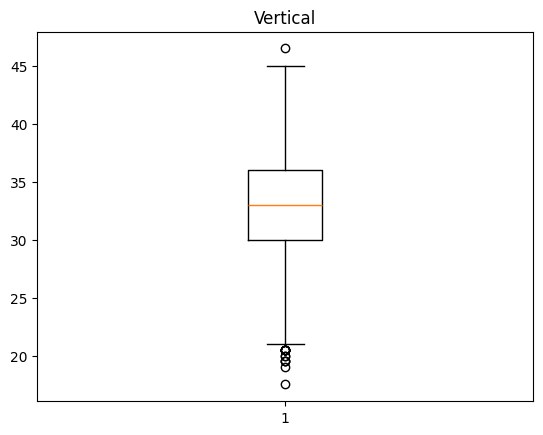

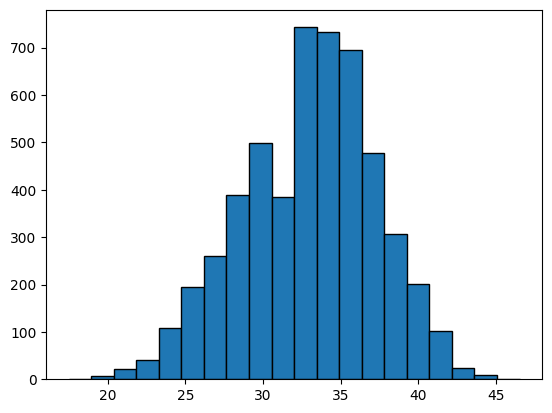

In [17]:
plt.boxplot(df['Vertical'].dropna())
plt.title('Vertical')
plt.show()
plt.hist(df['Vertical'].dropna(), bins=20, edgecolor='black');

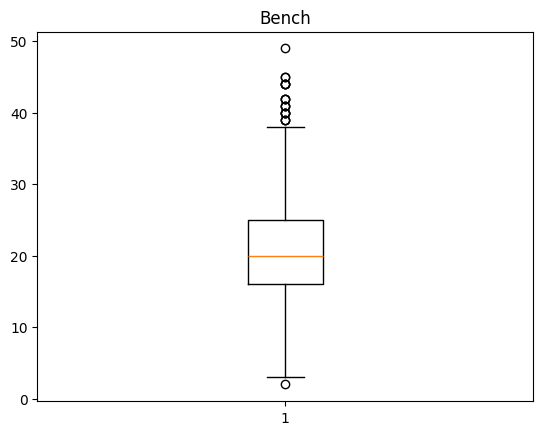

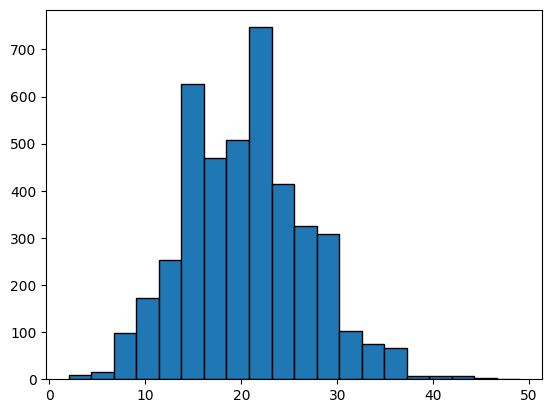

In [18]:
plt.boxplot(df['Bench'].dropna())
plt.title('Bench')
plt.show()
plt.hist(df['Bench'].dropna(), bins=20, edgecolor='black');

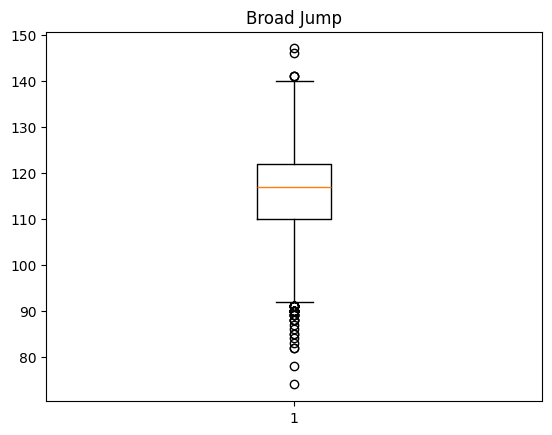

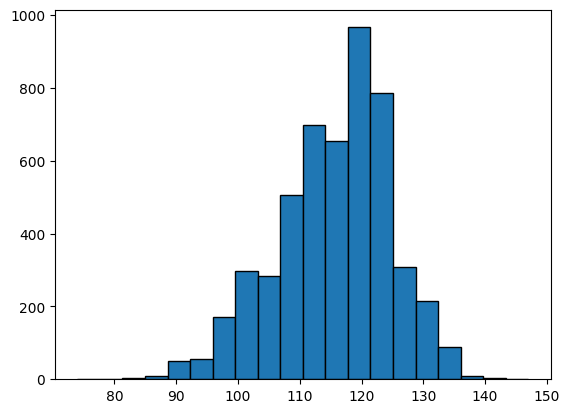

In [19]:
plt.boxplot(df['Broad Jump'].dropna())
plt.title('Broad Jump')
plt.show()
plt.hist(df['Broad Jump'].dropna(), bins=20, edgecolor='black');

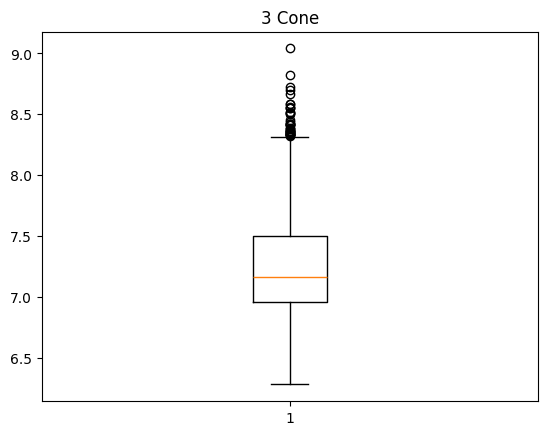

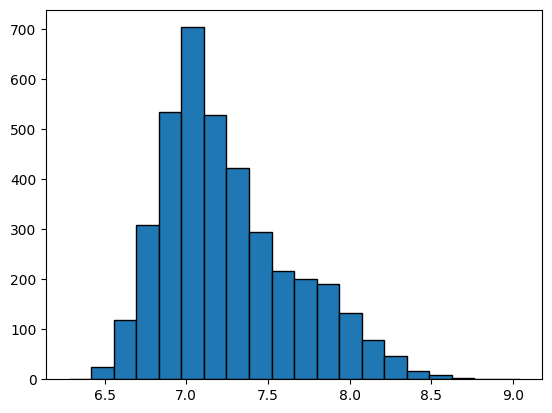

In [20]:
plt.boxplot(df['3Cone'].dropna())
plt.title('3 Cone')
plt.show()
plt.hist(df['3Cone'].dropna(), bins=20, edgecolor='black');

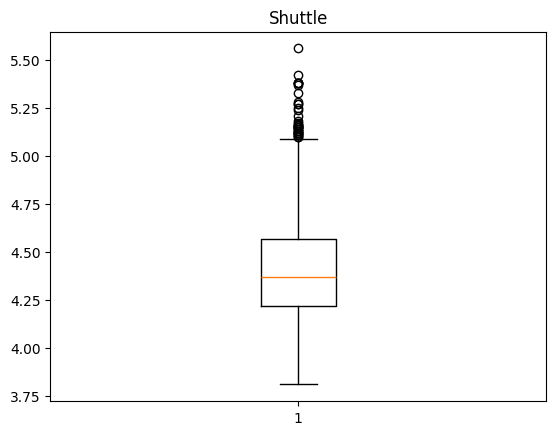

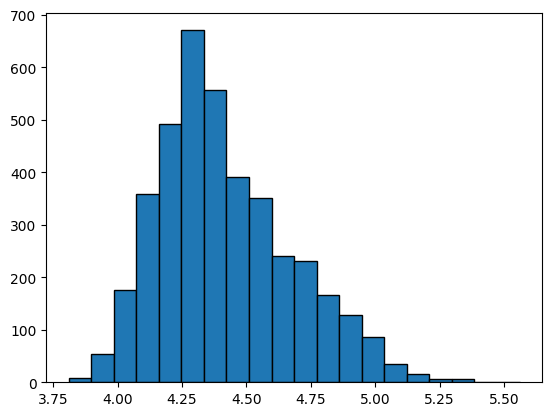

In [21]:
plt.boxplot(df['Shuttle'].dropna())
plt.title('Shuttle')
plt.show()
plt.hist(df['Shuttle'].dropna(), bins=20, edgecolor='black');

###Checking for Duplicates

In [22]:
df['Player'].duplicated().sum()

np.int64(76)

In [23]:
df[['Player','Pos']].duplicated().sum()

np.int64(10)

In [24]:
df[['Player','Pos','Year']].duplicated().sum()

np.int64(1)

In [25]:
df[df[['Player','Pos','Year']].duplicated()]

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year,Drafted
2571,Phillip Thomas,S,Defense,Fresno State,73.0,208.0,4.65,35.0,14.0,122.0,NaN,NaN,Washington Commanders,4.0,2013,1


In [26]:
df[df['Player']=='Phillip Thomas']

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year,Drafted
2253,Phillip Thomas,S,Defense,Syracuse,71.0,198.0,4.68,33.0,14.0,122.0,NaN,NaN,Washington Commanders,4.0,2013,1
2571,Phillip Thomas,S,Defense,Fresno State,73.0,208.0,4.65,35.0,14.0,122.0,NaN,NaN,Washington Commanders,4.0,2013,1


In [27]:
df[['Player','Pos','Year','School']].duplicated().sum()

np.int64(0)

###Comparing Metrics for past 20 years

In [28]:
cols=['Ht','Wt','40yd', 'Vertical','Bench','Broad Jump', '3Cone','Shuttle']
df2=df.groupby('Year')[cols].mean()

In [29]:
df2

,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle
Year,,,,,,,,
2006,73.987805,244.170732,4.770890,33.979323,21.746479,113.940075,7.272105,4.353602
2007,73.858896,241.273006,4.769815,32.898785,21.981735,113.562500,7.222028,4.423674
2008,73.724242,238.327273,4.758667,29.853846,21.658009,114.765625,7.233628,4.438565
2009,73.810398,244.574924,4.762362,33.099609,21.779592,112.582677,7.282679,4.447522
2010,73.907692,243.009231,4.763540,33.588933,21.004049,112.696850,7.205481,4.455187
2011,73.784848,244.136364,4.772424,32.556364,21.326848,113.308824,7.159482,4.361705
2012,73.656347,243.869969,4.756398,32.871698,21.504132,113.716535,7.230046,4.380541
2013,73.828313,244.771084,4.795843,32.367470,20.344538,115.391473,7.223713,4.429486
2014,73.858859,242.075075,4.778282,32.684015,20.308642,115.053435,7.249545,4.368153


In [30]:
df2.mean()

,0
Ht,73.958834
Wt,242.013394
40yd,4.752866
Vertical,32.943774
Bench,20.582670
Broad Jump,115.704867
3Cone,7.261575
Shuttle,4.423354


<Axes: xlabel='Year'>

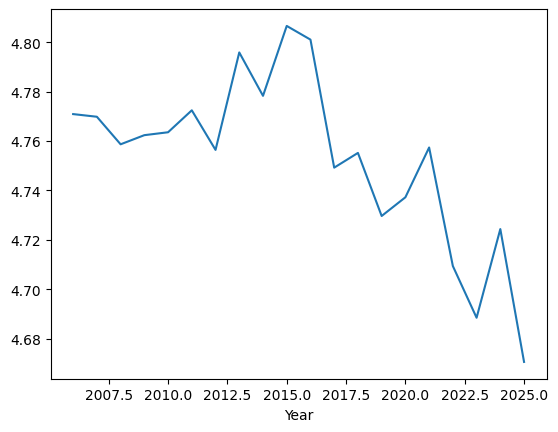

In [31]:
df2['40yd'].plot()

In [32]:
df.head()

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year,Drafted
0,Darrell Adams,DE,Defense,Villanova,77.0,277.0,5.00,27.0,22.0,109.0,7.91,4.76,NaN,NaN,2006,0
1,Titus Adams,DT,Defense,Nebraska,75.0,306.0,5.07,30.5,15.0,103.0,7.49,4.54,New York Jets,7.0,2006,1
2,Jahmile Addae,S,Defense,West Virginia,70.0,214.0,4.70,38.5,NaN,122.0,NaN,NaN,NaN,NaN,2006,0
3,Joseph Addai,RB,Offense,LSU,71.0,214.0,4.40,38.5,18.0,125.0,7.09,4.47,Indianapolis Colts,1.0,2006,1
4,Victor Adeyanju,DE,Defense,Indiana,76.0,274.0,4.86,32.0,22.0,112.0,7.37,4.41,Los Angeles Rams,4.0,2006,1


###Correlation to Drafted

In [33]:
df[['Ht','Wt','40yd','Vertical','Bench','Broad Jump','3Cone', 'Shuttle','Drafted']].corr().sort_values('Drafted',ascending=False)

,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Drafted
Drafted,0.062443,0.068109,-0.124623,0.134341,0.149273,0.126795,-0.079365,-0.102486,1.000000
Bench,0.355039,0.665217,0.493818,-0.321448,1.000000,-0.407696,0.467444,0.427975,0.149273
Vertical,-0.388385,-0.624501,-0.739911,1.000000,-0.321448,0.816607,-0.669795,-0.680179,0.134341
Broad Jump,-0.381243,-0.701022,-0.820324,0.816607,-0.407696,1.000000,-0.724117,-0.713380,0.126795
Wt,0.693391,1.000000,0.847729,-0.624501,0.665217,-0.701022,0.797654,0.771257,0.068109
Ht,1.000000,0.693391,0.574016,-0.388385,0.355039,-0.381243,0.476139,0.494519,0.062443
3Cone,0.476139,0.797654,0.815612,-0.669795,0.467444,-0.724117,1.000000,0.873347,-0.079365
Shuttle,0.494519,0.771257,0.796000,-0.680179,0.427975,-0.713380,0.873347,1.000000,-0.102486
40yd,0.574016,0.847729,1.000000,-0.739911,0.493818,-0.820324,0.815612,0.796000,-0.124623


In [34]:
df.groupby('Pos')[['Drafted','Round']].mean().sort_values(by='Round')

,Drafted,Round
Pos,,
CB/WR,1.000000,1.000000
EDGE,0.658385,3.481132
OT,0.680992,3.555825
QB,0.615385,3.587963
DE,0.721311,3.659091
CB,0.685161,3.689266
DT,0.716247,3.690096
OLB,0.738710,3.733624
WR,0.601695,3.850352


##Monte Carlo

### WR vs CB 2025_40yd

In [35]:
wr_40=df[(df['Pos'] == 'WR') &(df['Year']==2025)]['40yd'].dropna().tolist()
cb_40=df[(df['Pos'] == 'CB') &(df['Year']==2025)]['40yd'].dropna().tolist()

In [36]:
np.mean(wr_40)

np.float64(4.460000000000001)

In [37]:
len(wr_40)

39

In [38]:
np.mean(cb_40)

np.float64(4.442916666666667)

In [39]:
len(cb_40)

24

In [40]:
all_40=wr_40+ cb_40

In [41]:
len(all_40)

63

In [42]:
simu_diff=[]
for i in range(1000):
  perm_samp=np.random.permutation(all_40)
  perm_wr, perm_cb= perm_samp[:39], perm_samp[39:]
  perm_diff=np.mean(perm_wr)-np.mean(perm_cb)
  simu_diff.append(perm_diff)

In [43]:
mean_diff=np.mean(wr_40)-np.mean(cb_40)

In [44]:
upper=np.quantile(simu_diff, .975)
lower=np.quantile(simu_diff, .025)
print([lower, upper])

[np.float64(-0.04685897435897426), np.float64(0.04942467948718082)]


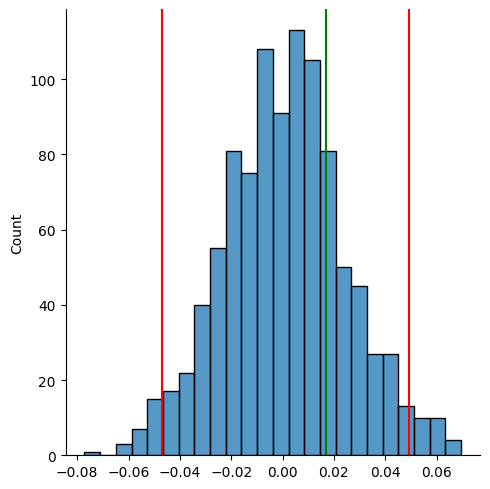

In [45]:
sns.displot(simu_diff)
plt.axvline(lower, color='red')
plt.axvline(upper, color='red')
plt.axvline(mean_diff, color='green')

###WR_25 vs WR_06 40yd

In [46]:
wr_25=df[(df['Pos'] == 'WR') &(df['Year']==2025)]['40yd'].dropna().tolist()
wr_06=df[(df['Pos'] == 'WR') &(df['Year']==2006)]['40yd'].dropna().tolist()

In [47]:
len(wr_25)

39

In [48]:
len(wr_06)

41

In [49]:
combined_wr= wr_25+wr_06

In [50]:
simu_diff2=[]
for i in range(1000):
  perm_samp2=np.random.permutation(combined_wr)
  perm_wr25, perm_wr06= perm_samp2[:39], perm_samp2[39:]
  perm_diff2=np.mean(perm_wr25)-np.mean(perm_wr06)
  simu_diff2.append(perm_diff2)

In [51]:
mean_diff=np.mean(wr_25)-np.mean(wr_06)
upper2=np.quantile(simu_diff2,.975)
lower2=np.quantile(simu_diff2,.025)

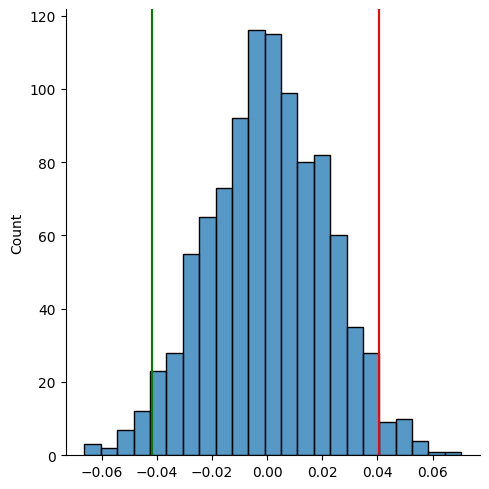

In [52]:
sns.displot(simu_diff2)
plt.axvline(lower2, color='red')
plt.axvline(upper2, color='red')
plt.axvline(mean_diff, color='green')

In [53]:
mean_diff

np.float64(-0.0417073170731701)

##Cluster

In [54]:
features = ['40yd', 'Vertical', 'Bench', 'Broad Jump', '3Cone', 'Shuttle']

X = df[features]
X = X.dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [55]:
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

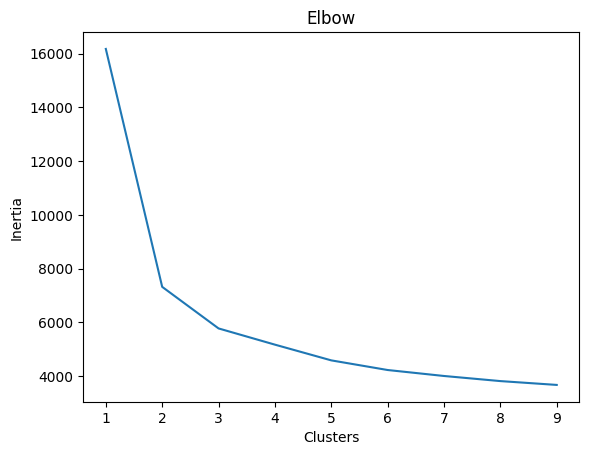

In [56]:
plt.plot(range(1, 10), inertia)
plt.xlabel('Clusters')
plt.ylabel('Inertia')
plt.title('Elbow')
plt.show()

In [57]:
kmeans = KMeans(n_clusters=3, random_state=42)
df.loc[X.index, 'Cluster'] = kmeans.fit_predict(X_scaled)
df.groupby('Cluster')[features].mean()

,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle
Cluster,,,,,,
0.0,4.525796,35.925152,16.268059,121.939077,6.950653,4.221784
1.0,5.225044,27.519679,25.459184,102.392128,7.817085,4.767026
2.0,4.768525,32.426829,22.838560,114.192799,7.237956,4.409686


In [58]:
cluster_names = {
    0: 'Elite',
    1: 'Strong',
    2: 'Balance'
}

df['Cluster'] = df['Cluster'].map(cluster_names)

In [59]:
df.groupby('Cluster')[features].mean().sort_values('40yd')

,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle
Cluster,,,,,,
Elite,4.525796,35.925152,16.268059,121.939077,6.950653,4.221784
Balance,4.768525,32.426829,22.838560,114.192799,7.237956,4.409686
Strong,5.225044,27.519679,25.459184,102.392128,7.817085,4.767026


In [60]:
df.groupby('Cluster')['Off_Def'].value_counts()

Cluster  Off_Def      
Balance  Defense          517
         Offense          339
         Special Teams      5
Elite    Defense          609
         Offense          540
Strong   Offense          492
         Defense          192
         Special Teams      2
Name: count, dtype: int64

In [61]:
df.head()

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year,Drafted,Cluster
0,Darrell Adams,DE,Defense,Villanova,77.0,277.0,5.00,27.0,22.0,109.0,7.91,4.76,NaN,NaN,2006,0,Strong
1,Titus Adams,DT,Defense,Nebraska,75.0,306.0,5.07,30.5,15.0,103.0,7.49,4.54,New York Jets,7.0,2006,1,Balance
2,Jahmile Addae,S,Defense,West Virginia,70.0,214.0,4.70,38.5,NaN,122.0,NaN,NaN,NaN,NaN,2006,0,NaN
3,Joseph Addai,RB,Offense,LSU,71.0,214.0,4.40,38.5,18.0,125.0,7.09,4.47,Indianapolis Colts,1.0,2006,1,Elite
4,Victor Adeyanju,DE,Defense,Indiana,76.0,274.0,4.86,32.0,22.0,112.0,7.37,4.41,Los Angeles Rams,4.0,2006,1,Balance


##Checking NAs

In [62]:
df.groupby('Year').apply(lambda x: x.isna().sum())

/tmp/ipykernel_838/3868836621.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Year').apply(lambda x: x.isna().sum())


,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year,Drafted,Cluster
Year,,,,,,,,,,,,,,,,,
2006,0,0,0,0,0,0,2,62,115,61,100,92,108,108,0,0,169
2007,0,0,0,0,0,0,2,79,107,86,109,111,113,113,0,0,179
2008,0,0,0,0,0,0,0,70,99,74,115,121,117,117,0,0,178
2009,0,0,0,0,0,0,1,71,82,73,103,97,117,117,0,0,150
2010,0,0,0,0,0,0,3,72,78,71,117,111,110,110,0,0,163
2011,0,0,0,0,0,0,0,55,73,58,79,72,111,111,0,0,127
2012,0,0,0,0,0,0,1,58,81,69,104,101,110,110,0,0,149
2013,0,0,0,0,0,0,0,83,94,74,130,118,108,108,0,0,172
2014,0,0,0,0,0,0,7,64,90,71,113,111,110,110,0,0,166


In [63]:
df.groupby('Pos').apply(lambda x: x.isna().sum())

/tmp/ipykernel_838/315016510.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Pos').apply(lambda x: x.isna().sum())


,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year,Drafted,Cluster
Pos,,,,,,,,,,,,,,,,,
C,0,0,0,0,0,0,22,40,58,42,55,51,64,64,0,0,77
CB,0,0,0,0,2,2,66,163,239,172,371,351,244,244,0,0,463
CB/WR,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,1
DE,0,0,0,0,4,3,33,96,108,102,161,160,136,136,0,0,231
DT,0,0,0,0,1,0,50,97,138,115,175,165,124,124,0,0,240
EDGE,0,0,0,0,0,0,53,45,72,48,111,105,55,55,0,0,131
FB,0,0,0,0,0,0,2,11,11,11,18,18,34,34,0,0,23
ILB,0,0,0,0,0,0,11,42,36,39,82,74,69,69,0,0,102
K,0,0,0,0,1,0,45,88,84,87,89,89,63,63,0,0,89


In [64]:
df_no_na=df[['Player','Ht','Wt','40yd', 'Vertical','Bench','Broad Jump','3Cone','Shuttle','Drafted']].dropna()

In [65]:
df_no_na

,Player,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Drafted
0,Darrell Adams,77.0,277.0,5.00,27.0,22.0,109.0,7.91,4.76,0
1,Titus Adams,75.0,306.0,5.07,30.5,15.0,103.0,7.49,4.54,1
3,Joseph Addai,71.0,214.0,4.40,38.5,18.0,125.0,7.09,4.47,1
4,Victor Adeyanju,76.0,274.0,4.86,32.0,22.0,112.0,7.37,4.41,1
5,Jason Allen,73.0,209.0,4.39,39.5,17.0,131.0,6.75,3.81,1
...,...,...,...,...,...,...,...,...,...,...
6601,Robbie Ouzts,75.0,274.0,4.91,34.0,26.0,119.0,7.34,4.45,1
6623,Ty Robinson,77.0,288.0,4.83,33.5,28.0,119.0,7.58,4.50,1
6650,Barryn Sorrell,75.0,256.0,4.68,34.0,28.0,121.0,7.06,4.36,1
6664,Isaac TeSlaa,76.0,214.0,4.43,39.5,17.0,129.0,6.85,4.05,1


In [66]:
x_test=df_no_na[['Ht', 'Wt','40yd','Vertical','Broad Jump','3Cone','Shuttle']]
y_test=df_no_na['Drafted']

In [67]:
scaler = StandardScaler()
x_scaler=scaler.fit_transform(x_test)

In [68]:
model = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, x_scaler, y_test, cv=5)
scores.mean(), scores.std()

(np.float64(0.7121214420205393), np.float64(0.02509737800002242))

##QBs

Logistic regression is a classification algorithm used to predict binary categories

In [69]:
df_qb=df[df['Pos']=='QB']
#df_qb=df[(df['Pos']=='QB') & (df['Year'].isin([2021,2022,2023,2024,2025]))]
df_qb.head()

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year,Drafted,Cluster
15,Brett Basanez,QB,Offense,Northwestern,73.0,220.0,4.76,34.0,NaN,114.0,6.75,4.22,NaN,NaN,2006,0,NaN
46,Kellen Clemens,QB,Offense,Oregon,74.0,224.0,4.89,NaN,NaN,NaN,NaN,NaN,New York Jets,2.0,2006,1,NaN
52,Brodie Croyle,QB,Offense,Alabama,74.0,205.0,4.88,30.5,NaN,104.0,7.34,4.25,Kansas City Chiefs,3.0,2006,1,NaN
53,Jay Cutler,QB,Offense,Vanderbilt,75.0,226.0,4.77,NaN,23.0,NaN,7.10,4.26,Denver Broncos,1.0,2006,1,NaN
71,Bruce Eugene,QB,Offense,Grambling State,73.0,260.0,5.12,27.5,NaN,94.0,7.97,4.76,NaN,NaN,2006,0,NaN


In [70]:
df_qb=df_qb.drop(columns='Bench')
df_qb

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Broad Jump,3Cone,Shuttle,Team,Round,Year,Drafted,Cluster
15,Brett Basanez,QB,Offense,Northwestern,73.0,220.0,4.76,34.0,114.0,6.75,4.22,NaN,NaN,2006,0,NaN
46,Kellen Clemens,QB,Offense,Oregon,74.0,224.0,4.89,NaN,NaN,NaN,NaN,New York Jets,2.0,2006,1,NaN
52,Brodie Croyle,QB,Offense,Alabama,74.0,205.0,4.88,30.5,104.0,7.34,4.25,Kansas City Chiefs,3.0,2006,1,NaN
53,Jay Cutler,QB,Offense,Vanderbilt,75.0,226.0,4.77,NaN,NaN,7.10,4.26,Denver Broncos,1.0,2006,1,NaN
71,Bruce Eugene,QB,Offense,Grambling State,73.0,260.0,5.12,27.5,94.0,7.97,4.76,NaN,NaN,2006,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6580,Jalen Milroe,QB,Offense,Alabama,74.0,217.0,NaN,NaN,NaN,NaN,NaN,Seattle Seahawks,3.0,2025,1,NaN
6625,Kurtis Rourke,QB,Offense,Indiana,76.0,220.0,NaN,NaN,NaN,NaN,NaN,San Francisco 49ers,7.0,2025,1,NaN
6630,Shedeur Sanders,QB,Offense,Colorado,74.0,212.0,NaN,NaN,NaN,NaN,NaN,Cleveland Browns,5.0,2025,1,NaN
6638,Tyler Shough,QB,Offense,Louisville,77.0,219.0,4.63,32.0,117.0,NaN,NaN,New Orleans Saints,2.0,2025,1,NaN


In [71]:
df_qb=df_qb[['Player','Ht','Wt','40yd', 'Vertical','Broad Jump','3Cone','Shuttle','Drafted']].dropna()
df_qb

,Player,Ht,Wt,40yd,Vertical,Broad Jump,3Cone,Shuttle,Drafted
15,Brett Basanez,73.0,220.0,4.76,34.0,114.0,6.75,4.22,0
52,Brodie Croyle,74.0,205.0,4.88,30.5,104.0,7.34,4.25,1
71,Bruce Eugene,73.0,260.0,5.12,27.5,94.0,7.97,4.76,0
82,Bruce Gradkowski,73.0,217.0,4.59,34.0,107.0,7.12,4.16,1
87,Darrell Hackney,73.0,239.0,4.82,33.0,110.0,7.62,4.69,0
...,...,...,...,...,...,...,...,...,...
6018,Clayton Tune,75.0,220.0,4.64,37.5,122.0,6.89,4.25,1
6164,Sam Hartman,73.0,211.0,4.80,28.5,109.0,7.19,4.34,0
6285,Spencer Rattler,73.0,211.0,4.95,32.0,108.0,7.21,4.37,1
6424,Brady Cook,74.0,214.0,4.59,37.0,128.0,7.01,4.17,0


In [72]:
df_qb['Drafted'].value_counts()

,count
Drafted,
1,127
0,105


In [73]:
df_qb.isna().sum().sum()

np.int64(0)

In [74]:
x1=df_qb[['40yd', 'Vertical','Broad Jump','3Cone','Shuttle']]
y1=df_qb['Drafted']

###Logistic Regression

In [75]:
scaler = StandardScaler()
x_scaler1=scaler.fit_transform(x1)
xtrain1, xtest1, ytrain1, ytest1 = train_test_split(x_scaler1,y1, test_size=.2, random_state=42)
model1 = LogisticRegression(max_iter=1000)

param_grid = [
   # L2 regularization
   {
       'penalty': ['l2'],
       'C': [0.001, 0.01, 0.1, 1, 10, 100],
       'solver': ['lbfgs']
   },
   # L1 regularization
   {
       'penalty': ['l1'],
       'C': [0.001, 0.01, 0.1, 1, 10, 100],
       'solver': ['liblinear']
   }
]

grid = GridSearchCV(
   model,
   param_grid,
   cv=5,
   scoring='f1',
   n_jobs=-1
)

grid.fit(xtrain1, ytrain1)

print(grid.best_params_)
print(grid.best_score_)

{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
0.712927849348564


In [76]:
model1 = LogisticRegression(max_iter=1000, C= 0.01, penalty= 'l2', solver= 'lbfgs')
scores1 = cross_val_score(model1, x_scaler1, y1, cv=5, scoring='f1')
scores1.mean(), scores1.std()

(np.float64(0.6850135904771275), np.float64(0.053187301901770304))

###Random Forest

machine learning model that uses many decision trees to make a prediction.  where the oob score tells you how well you can use it to predict unseen data.

In [77]:
rf1 = rfc(
   random_state=42,
   n_jobs=-1
)

param_dist = {
   'n_estimators': [100, 300, 500, 800],
   'max_depth': [None, 10, 20, 40],
   'max_features': ['sqrt', 'log2', None],
  'min_samples_split': [2, 5, 10, 20],
  'min_samples_leaf': [1, 2, 5, 10],
   'bootstrap': [True]
}

search = RandomizedSearchCV(
   estimator=rf1,
  param_distributions=param_dist,
   n_iter=30,
   cv=5,
   scoring='f1',      # change as needed
   n_jobs=-1, # all computer cores used
   random_state=42,
   refit=True
)

search.fit(xtrain1, ytrain1)

print(search.best_params_)
print(search.best_score_)
best_rf1 = search.best_estimator_

best_rf1.predict(xtest1)
best_rf1.predict_proba(xtest1)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}
0.6746489504892865


array([[0.31533013, 0.68466987],
       [0.47917207, 0.52082793],
       [0.28619725, 0.71380275],
       [0.54431107, 0.45568893],
       [0.42991925, 0.57008075],
       [0.39453086, 0.60546914],
       [0.6379672 , 0.3620328 ],
       [0.46572817, 0.53427183],
       [0.4385319 , 0.5614681 ],
       [0.50585385, 0.49414615],
       [0.34197956, 0.65802044],
       [0.4091243 , 0.5908757 ],
       [0.52334106, 0.47665894],
       [0.41619097, 0.58380903],
       [0.42962861, 0.57037139],
       [0.59561818, 0.40438182],
       [0.71906764, 0.28093236],
       [0.68423316, 0.31576684],
       [0.37051288, 0.62948712],
       [0.40931518, 0.59068482],
       [0.52766242, 0.47233758],
       [0.45706935, 0.54293065],
       [0.3706898 , 0.6293102 ],
       [0.63976192, 0.36023808],
       [0.33643339, 0.66356661],
       [0.56094438, 0.43905562],
       [0.31632112, 0.68367888],
       [0.57619997, 0.42380003],
       [0.50768006, 0.49231994],
       [0.39631128, 0.60368872],
       [0.

In [78]:
rf1=rfc(n_estimators=300, oob_score=True, min_samples_split=5, min_samples_leaf=10, max_features='log2', max_depth=20, bootstrap=True)
rf1.fit(xtrain1, ytrain1)

RandomForestClassifier(max_depth=20, max_features='log2', min_samples_leaf=10,
                       min_samples_split=5, n_estimators=300, oob_score=True)

In [79]:
rf1.oob_score_

0.5297297297297298

In [80]:
rf1.score(xtest1, ytest1)

0.425531914893617

In [81]:
mutual_info_classif(xtrain1, ytrain1)

array([0.        , 0.0220465 , 0.        , 0.03149576, 0.        ])

###Confusion Matrix

In [82]:
ytest1.shape

(47,)

In [83]:
y1_pred=rf1.predict(xtest1)
y1_pred.shape

(47,)

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

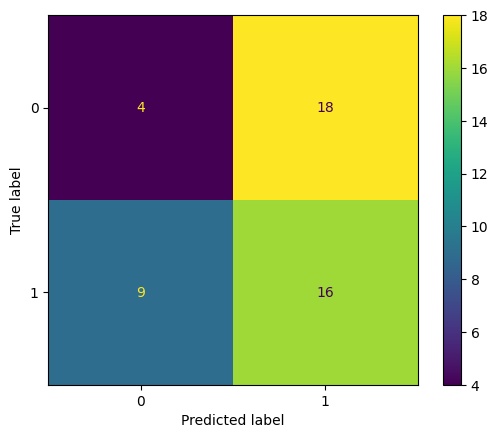

In [85]:
cm = confusion_matrix(ytest1, y1_pred)
cmd = ConfusionMatrixDisplay(cm) #display_labels = label_encoder.classes_)
cmd.plot()

In [86]:
21/47

0.44680851063829785

##WRs

In [87]:
dfwr=df[df['Pos']=='WR']
dfwr.head()

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year,Drafted,Cluster
8,David Anderson,WR,Offense,Colorado State,70.0,192.0,4.57,34.0,NaN,116.0,6.88,4.20,Houston Texans,7.0,2006,1,NaN
12,Devin Aromashodu,WR,Offense,Auburn,74.0,201.0,4.35,39.0,NaN,120.0,7.04,4.16,Miami Dolphins,7.0,2006,1,NaN
13,Miles Austin,WR,Offense,Monmouth (NJ),74.0,215.0,4.47,40.5,21.0,123.0,7.09,4.14,NaN,NaN,2006,0,Elite
14,Jason Avant,WR,Offense,Michigan,73.0,212.0,4.62,37.0,20.0,118.0,NaN,NaN,Philadelphia Eagles,4.0,2006,1,NaN
16,Hank Baskett,WR,Offense,New Mexico,75.0,224.0,4.50,35.0,NaN,119.0,6.79,4.17,NaN,NaN,2006,0,NaN


In [88]:
dfwr.Drafted.value_counts()

,count
Drafted,
1,568
0,376


In [89]:
dfwr=dfwr.drop(columns=['Bench','3Cone','Shuttle'])
dfwr

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Broad Jump,Team,Round,Year,Drafted,Cluster
8,David Anderson,WR,Offense,Colorado State,70.0,192.0,4.57,34.0,116.0,Houston Texans,7.0,2006,1,NaN
12,Devin Aromashodu,WR,Offense,Auburn,74.0,201.0,4.35,39.0,120.0,Miami Dolphins,7.0,2006,1,NaN
13,Miles Austin,WR,Offense,Monmouth (NJ),74.0,215.0,4.47,40.5,123.0,NaN,NaN,2006,0,Elite
14,Jason Avant,WR,Offense,Michigan,73.0,212.0,4.62,37.0,118.0,Philadelphia Eagles,4.0,2006,1,NaN
16,Hank Baskett,WR,Offense,New Mexico,75.0,224.0,4.50,35.0,119.0,NaN,NaN,2006,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6682,Jordan Watkins,WR,Offense,Mississippi,71.0,196.0,4.37,36.5,119.0,NaN,NaN,2025,0,NaN
6685,Theo Wease,WR,Offense,Missouri,75.0,200.0,4.56,31.0,117.0,NaN,NaN,2025,0,NaN
6688,LaJohntay Wester,WR,Offense,Colorado,70.0,163.0,4.46,32.0,121.0,Baltimore Ravens,6.0,2025,1,NaN
6691,Kyle Williams,WR,Offense,Washington St.,71.0,190.0,4.40,36.5,119.0,New England Patriots,3.0,2025,1,NaN


In [90]:
dfwr=dfwr[['Player','Ht','Wt','40yd', 'Vertical','Broad Jump','Drafted']].dropna()
dfwr

,Player,Ht,Wt,40yd,Vertical,Broad Jump,Drafted
8,David Anderson,70.0,192.0,4.57,34.0,116.0,1
12,Devin Aromashodu,74.0,201.0,4.35,39.0,120.0,1
13,Miles Austin,74.0,215.0,4.47,40.5,123.0,0
14,Jason Avant,73.0,212.0,4.62,37.0,118.0,1
16,Hank Baskett,75.0,224.0,4.50,35.0,119.0,0
...,...,...,...,...,...,...,...
6664,Isaac TeSlaa,76.0,214.0,4.43,39.5,129.0,1
6682,Jordan Watkins,71.0,196.0,4.37,36.5,119.0,0
6685,Theo Wease,75.0,200.0,4.56,31.0,117.0,0
6688,LaJohntay Wester,70.0,163.0,4.46,32.0,121.0,1


In [91]:
dfwr.Drafted.value_counts()

,count
Drafted,
1,456
0,294


In [92]:
dfwr.isna().sum().sum()

np.int64(0)

In [93]:
x2=dfwr[['40yd', 'Vertical','Broad Jump']]
y2=dfwr['Drafted']

###Logistic Regression

In [94]:
scaler = StandardScaler()
x_scaler2=scaler.fit_transform(x2)
xtrain2, xtest2, ytrain2, ytest2 = train_test_split(x_scaler2,y2, test_size=.2, random_state=42)
model2 = LogisticRegression(max_iter=1000)

param_grid = [
   # L2 regularization
   {
       'penalty': ['l2'],
       'C': [0.001, 0.01, 0.1, 1, 10, 100],
       'solver': ['lbfgs']
   },
   # L1 regularization
   {
       'penalty': ['l1'],
       'C': [0.001, 0.01, 0.1, 1, 10, 100],
       'solver': ['liblinear']
   }
]

grid = GridSearchCV(
   model,
   param_grid,
   cv=5,
   scoring='f1',
   n_jobs=-1
)

grid.fit(xtrain2, ytrain2)

print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.7787680276133833


In [95]:
model2 = LogisticRegression(max_iter=1000, C= .1, penalty= 'l2', solver= 'lbfgs')
scores2 = cross_val_score(model2, x_scaler2, y2, cv=5, scoring='f1')
scores2.mean(), scores2.std()

(np.float64(0.7693063119718128), np.float64(0.028035373220157356))

###Random Forest

In [96]:
rf2 = rfc(
   random_state=42,
   n_jobs=-1
)

param_dist = {
   'n_estimators': [100, 300, 500, 800],
   'max_depth': [None, 10, 20, 40],
   'max_features': ['sqrt', 'log2', None],
  'min_samples_split': [2, 5, 10, 20],
  'min_samples_leaf': [1, 2, 5, 10],
   'bootstrap': [True]
}

search = RandomizedSearchCV(
   estimator=rf2,
  param_distributions=param_dist,
   n_iter=30,
   cv=5,
   scoring='f1',      # change as needed
   n_jobs=-1, # all computer cores used
   random_state=42,
   refit=True
)

search.fit(xtrain2, ytrain2)

print(search.best_params_)
print(search.best_score_)
best_rf = search.best_estimator_

best_rf.predict(xtest2)
best_rf.predict_proba(xtest2)

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 20, 'bootstrap': True}
0.7520685180407755


array([[0.36962068, 0.63037932],
       [0.53458403, 0.46541597],
       [0.71342538, 0.28657462],
       [0.05982285, 0.94017715],
       [0.28476524, 0.71523476],
       [0.31506723, 0.68493277],
       [0.6451831 , 0.3548169 ],
       [0.44999549, 0.55000451],
       [0.38121437, 0.61878563],
       [0.06321663, 0.93678337],
       [0.73960565, 0.26039435],
       [0.78379098, 0.21620902],
       [0.46668553, 0.53331447],
       [0.16114569, 0.83885431],
       [0.40038145, 0.59961855],
       [0.72765045, 0.27234955],
       [0.79370125, 0.20629875],
       [0.55268719, 0.44731281],
       [0.1305243 , 0.8694757 ],
       [0.23291177, 0.76708823],
       [0.12728223, 0.87271777],
       [0.16394747, 0.83605253],
       [0.38661361, 0.61338639],
       [0.07330514, 0.92669486],
       [0.01936983, 0.98063017],
       [0.38788353, 0.61211647],
       [0.17757388, 0.82242612],
       [0.23239241, 0.76760759],
       [0.02280905, 0.97719095],
       [0.36357288, 0.63642712],
       [0.

In [97]:
rf2=rfc(n_estimators= 100,oob_score=True, min_samples_split= 10, min_samples_leaf= 10, max_features= None, max_depth= 20, bootstrap= True)
rf2.fit(xtrain2,ytrain2)

RandomForestClassifier(max_depth=20, max_features=None, min_samples_leaf=10,
                       min_samples_split=10, oob_score=True)

In [98]:
rf2.oob_score_

0.6716666666666666

In [99]:
rf2.score(xtest2,ytest2)

0.66

In [100]:
mutual_info_classif(xtrain2, ytrain2)

array([0.09932262, 0.        , 0.06025951])

###Confusion Matrix

In [101]:
y2_pred=rf2.predict(xtest2)

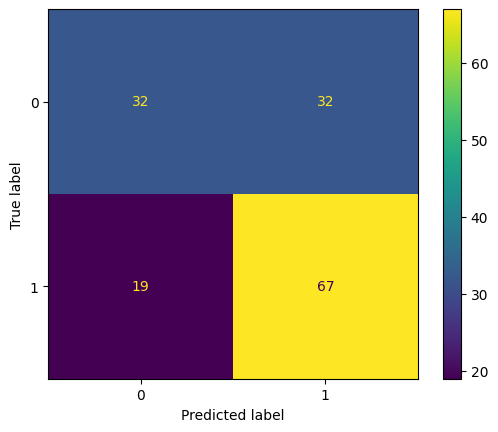

In [102]:
cm = confusion_matrix(ytest2, y2_pred)
cmd = ConfusionMatrixDisplay(cm) #display_labels = label_encoder.classes_)
cmd.plot()

In [103]:
98/150

0.6533333333333333

##LR for Edge

In [104]:
df.Pos.unique()

array(['DE', 'DT', 'S', 'RB', 'OLB', 'WR', 'QB', 'P', 'FB', 'TE', 'CB',
       'OT', 'ILB', 'C', 'K', 'OG', 'LS', 'EDGE', 'LB', 'CB/WR'],
      dtype=object)

In [105]:
df_edge=df[(df['Pos']=='DE') | (df['Pos']=='EDGE')]
df_edge

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Team,Round,Year,Drafted,Cluster
0,Darrell Adams,DE,Defense,Villanova,77.0,277.0,5.00,27.0,22.0,109.0,7.91,4.76,NaN,NaN,2006,0,Strong
4,Victor Adeyanju,DE,Defense,Indiana,76.0,274.0,4.86,32.0,22.0,112.0,7.37,4.41,Los Angeles Rams,4.0,2006,1,Balance
10,Mark Anderson,DE,Defense,Alabama,76.0,254.0,4.62,42.0,20.0,127.0,6.95,4.22,Chicago Bears,5.0,2006,1,Elite
19,Charles Bennett,DE,Defense,Clemson,76.0,258.0,4.70,33.5,19.0,115.0,7.48,4.52,Tampa Bay Buccaneers,7.0,2006,1,Balance
34,Copeland Bryan,DE,Defense,Arizona,76.0,253.0,4.90,33.0,16.0,117.0,7.11,4.30,NaN,NaN,2006,0,Balance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6658,Bradyn Swinson,EDGE,Defense,LSU,76.0,255.0,NaN,NaN,NaN,NaN,7.13,4.33,New England Patriots,5.0,2025,1,NaN
6670,JT Tuimoloau,EDGE,Defense,Ohio St.,76.0,265.0,NaN,NaN,NaN,NaN,NaN,NaN,Indianapolis Colts,2.0,2025,1,NaN
6673,Princely Umanmielen,EDGE,Defense,Mississippi,76.0,244.0,4.72,38.0,NaN,126.0,7.33,4.46,Carolina Panthers,3.0,2025,1,NaN
6676,David Walker,EDGE,Defense,Central Arkansas,73.0,263.0,4.69,35.0,26.0,118.0,7.15,4.39,NaN,NaN,2025,0,Balance


In [106]:
df_edge.Drafted.value_counts()

,count
Drafted,
1,458
0,191


In [107]:
df_edge=df_edge.drop(columns=['3Cone','Shuttle'])
df_edge

,Player,Pos,Off_Def,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,Team,Round,Year,Drafted,Cluster
0,Darrell Adams,DE,Defense,Villanova,77.0,277.0,5.00,27.0,22.0,109.0,NaN,NaN,2006,0,Strong
4,Victor Adeyanju,DE,Defense,Indiana,76.0,274.0,4.86,32.0,22.0,112.0,Los Angeles Rams,4.0,2006,1,Balance
10,Mark Anderson,DE,Defense,Alabama,76.0,254.0,4.62,42.0,20.0,127.0,Chicago Bears,5.0,2006,1,Elite
19,Charles Bennett,DE,Defense,Clemson,76.0,258.0,4.70,33.5,19.0,115.0,Tampa Bay Buccaneers,7.0,2006,1,Balance
34,Copeland Bryan,DE,Defense,Arizona,76.0,253.0,4.90,33.0,16.0,117.0,NaN,NaN,2006,0,Balance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6658,Bradyn Swinson,EDGE,Defense,LSU,76.0,255.0,NaN,NaN,NaN,NaN,New England Patriots,5.0,2025,1,NaN
6670,JT Tuimoloau,EDGE,Defense,Ohio St.,76.0,265.0,NaN,NaN,NaN,NaN,Indianapolis Colts,2.0,2025,1,NaN
6673,Princely Umanmielen,EDGE,Defense,Mississippi,76.0,244.0,4.72,38.0,NaN,126.0,Carolina Panthers,3.0,2025,1,NaN
6676,David Walker,EDGE,Defense,Central Arkansas,73.0,263.0,4.69,35.0,26.0,118.0,NaN,NaN,2025,0,Balance


In [108]:
df_edge=df_edge[['Player','Ht','Wt','40yd', 'Vertical','Bench','Broad Jump','Drafted']].dropna()
df_edge

,Player,Ht,Wt,40yd,Vertical,Bench,Broad Jump,Drafted
0,Darrell Adams,77.0,277.0,5.00,27.0,22.0,109.0,0
4,Victor Adeyanju,76.0,274.0,4.86,32.0,22.0,112.0,1
10,Mark Anderson,76.0,254.0,4.62,42.0,20.0,127.0,1
19,Charles Bennett,76.0,258.0,4.70,33.5,19.0,115.0,1
34,Copeland Bryan,76.0,253.0,4.90,33.0,16.0,117.0,0
...,...,...,...,...,...,...,...,...
6436,Ethan Downs,76.0,269.0,4.69,34.0,32.0,119.0,0
6477,Ahmed Hassanein,74.0,267.0,4.77,32.5,27.0,113.0,1
6563,Sean Martin,78.0,293.0,4.88,28.5,28.0,112.0,0
6650,Barryn Sorrell,75.0,256.0,4.68,34.0,28.0,121.0,1


In [109]:
df_edge.Drafted.value_counts()

,count
Drafted,
1,254
0,111


In [110]:
df_edge.isna().sum().sum()

np.int64(0)

In [111]:
x3=df_edge[['40yd', 'Vertical','Bench','Broad Jump']]
y3=df_edge['Drafted']

###Logistic Regression

In [112]:
scaler = StandardScaler()
x_scaler3=scaler.fit_transform(x3)
xtrain3, xtest3, ytrain3, ytest3 = train_test_split(x_scaler3,y3, test_size=.2, random_state=42)
model = LogisticRegression(max_iter=1000)

param_grid = [
   # L2 regularization
   {
       'penalty': ['l2'],
       'C': [0.001, 0.01, 0.1, 1, 10, 100],
       'solver': ['lbfgs']
   },
   # L1 regularization
   {
       'penalty': ['l1'],
       'C': [0.001, 0.01, 0.1, 1, 10, 100],
       'solver': ['liblinear']
   }
]

grid = GridSearchCV(
   model,
   param_grid,
   cv=5,
   scoring='f1',
   n_jobs=-1
)

grid.fit(xtrain3, ytrain3)

print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.8297443984493068


In [113]:
model = LogisticRegression(max_iter=1000,C= 0.1, penalty= 'l2', solver= 'lbfgs')
scores = cross_val_score(model, x_scaler3, y3, cv=5)
scores.mean(), scores.std()

(np.float64(0.715068493150685), np.float64(0.026562629355705913))

###Random Forest

In [114]:
rf3 = rfc(
   random_state=42,
   n_jobs=-1
)

param_dist = {
   'n_estimators': [100, 300, 500, 800],
   'max_depth': [None, 10, 20, 40],
   'max_features': ['sqrt', 'log2', None],
  'min_samples_split': [2, 5, 10, 20],
  'min_samples_leaf': [1, 2, 5, 10],
   'bootstrap': [True]
}

search = RandomizedSearchCV(
   estimator=rf3,
  param_distributions=param_dist,
   n_iter=30,
   cv=5,
   scoring='f1',      # change as needed
   n_jobs=-1, # all computer cores used
   random_state=42,
   refit=True
)

search.fit(xtrain3, ytrain3)

print(search.best_params_)
print(search.best_score_)
best_rf = search.best_estimator_

best_rf.predict(xtest3)
best_rf.predict_proba(xtest3)

{'n_estimators': 800, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': True}
0.8340448060831097


array([[0.10595146, 0.89404854],
       [0.600617  , 0.399383  ],
       [0.31377971, 0.68622029],
       [0.57045896, 0.42954104],
       [0.23804977, 0.76195023],
       [0.0954141 , 0.9045859 ],
       [0.43806666, 0.56193334],
       [0.17543887, 0.82456113],
       [0.3069251 , 0.6930749 ],
       [0.48040607, 0.51959393],
       [0.03922477, 0.96077523],
       [0.7999764 , 0.2000236 ],
       [0.50263276, 0.49736724],
       [0.61847763, 0.38152237],
       [0.04541065, 0.95458935],
       [0.26076264, 0.73923736],
       [0.62200583, 0.37799417],
       [0.42431265, 0.57568735],
       [0.74640513, 0.25359487],
       [0.59811242, 0.40188758],
       [0.45481078, 0.54518922],
       [0.43046114, 0.56953886],
       [0.71049147, 0.28950853],
       [0.22039012, 0.77960988],
       [0.5439405 , 0.4560595 ],
       [0.56309145, 0.43690855],
       [0.05661228, 0.94338772],
       [0.41458514, 0.58541486],
       [0.0953464 , 0.9046536 ],
       [0.15477803, 0.84522197],
       [0.

In [115]:
rf3=rfc(n_estimators= 800, oob_score=True, min_samples_split= 20, min_samples_leaf= 10, max_features= 'sqrt', max_depth= 40, bootstrap= True)
rf3.fit(xtrain3,ytrain3)

RandomForestClassifier(max_depth=40, min_samples_leaf=10, min_samples_split=20,
                       n_estimators=800, oob_score=True)

In [116]:
rf3.oob_score_

0.7397260273972602

In [117]:
rf3.score(xtest3,ytest3)

0.7534246575342466

In [118]:
mutual_info_classif(xtrain3, ytrain3)

array([0.09191886, 0.04181162, 0.00406977, 0.05128472])

###Confusion Matrix

In [119]:
y3_pred=rf3.predict(xtest3)

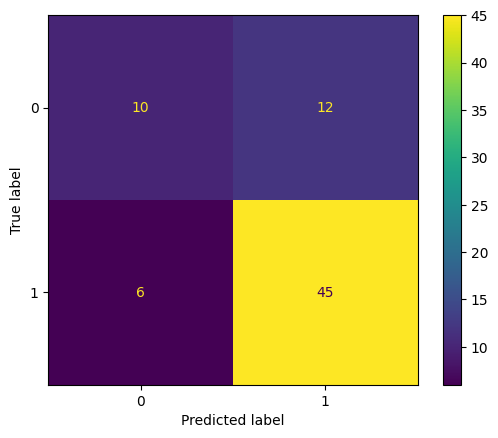

In [120]:
cm = confusion_matrix(ytest3, y3_pred)
cmd = ConfusionMatrixDisplay(cm) #display_labels = label_encoder.classes_)
cmd.plot()

In [121]:
54/73

0.7397260273972602

##QB Stats  2016-25



In [122]:
df_stats = pd.read_csv('https://raw.githubusercontent.com/ccyang8792/ccyang8792.github.io/main/CapStone/qb_stats.csv')

In [123]:
df_stats

,Player,Pos,School,Round,updated_round,Drafted,Year,game,completion,attempt,yard,td,int
0,Kyle McCord,QB,Syracuse,6.0,6,1,2025,13,391,592,4779,34,12
1,Cameron Ward,QB,Miami,1.0,1,1,2025,13,305,454,4313,39,7
2,Jaxson Dart,QB,Mississippi,1.0,1,1,2025,13,276,398,4279,29,6
3,Shedeur Sanders,QB,Colorado,5.0,5,1,2025,13,353,477,4134,37,10
4,Will Howard,QB,Ohio St.,6.0,6,1,2025,16,309,423,4010,35,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,Joel Stave,QB,Wisconsin,NaN,0,0,2016,13,225,370,2687,11,11
144,Jacoby Brissett,QB,North Carolina State,3.0,3,1,2016,13,237,395,2662,20,6
145,Vernon Adams,QB,Oregon,NaN,0,0,2016,10,168,259,2643,26,6
146,Christian Hackenberg,QB,Penn State,2.0,2,1,2016,13,192,359,2525,16,6


In [124]:
df_stats.Drafted.value_counts()

,count
Drafted,
1,104
0,44


In [125]:
df_stats.isna().sum()

,0
Player,0
Pos,0
School,0
Round,44
updated_round,0
Drafted,0
Year,0
game,0
completion,0
attempt,0


In [126]:
df_stats=df_stats.drop(columns='Round')

In [127]:
df_stats[['game','completion','attempt','yard','td','int','updated_round']].corr()

,game,completion,attempt,yard,td,int,updated_round
game,1.000000,0.605705,0.631358,0.637444,0.499010,0.343266,0.145540
completion,0.605705,1.000000,0.964130,0.923836,0.769506,0.416483,0.098803
attempt,0.631358,0.964130,1.000000,0.877282,0.694196,0.531147,0.075605
yard,0.637444,0.923836,0.877282,1.000000,0.879761,0.323736,0.054254
td,0.499010,0.769506,0.694196,0.879761,1.000000,0.199752,0.028070
int,0.343266,0.416483,0.531147,0.323736,0.199752,1.000000,-0.030990
updated_round,0.145540,0.098803,0.075605,0.054254,0.028070,-0.030990,1.000000


In [128]:
df_stats[['game','completion','attempt','yard','td','int','Drafted']].corr()

,game,completion,attempt,yard,td,int,Drafted
game,1.000000,0.605705,0.631358,0.637444,0.499010,0.343266,0.205912
completion,0.605705,1.000000,0.964130,0.923836,0.769506,0.416483,0.221321
attempt,0.631358,0.964130,1.000000,0.877282,0.694196,0.531147,0.158271
yard,0.637444,0.923836,0.877282,1.000000,0.879761,0.323736,0.281525
td,0.499010,0.769506,0.694196,0.879761,1.000000,0.199752,0.287547
int,0.343266,0.416483,0.531147,0.323736,0.199752,1.000000,-0.096213
Drafted,0.205912,0.221321,0.158271,0.281525,0.287547,-0.096213,1.000000


In [129]:
qb_x=df_stats[['game','completion','attempt','yard','td','int']]
qb_y=df_stats['Drafted']

###Logistic Regression

In [130]:
scaler = StandardScaler()
x_scaler4=scaler.fit_transform(qb_x)
xtrain4, xtest4, ytrain4, ytest4 = train_test_split(x_scaler4,qb_y, test_size=.2, random_state=42)
model = LogisticRegression(max_iter=1000)

param_grid = [
   # L2 regularization
   {
       'penalty': ['l2'],
       'C': [0.001, 0.01, 0.1, 1, 10, 100],
       'solver': ['lbfgs']
   },
   # L1 regularization
   {
       'penalty': ['l1'],
       'C': [0.001, 0.01, 0.1, 1, 10, 100],
       'solver': ['liblinear']
   }
]

grid = GridSearchCV(
   model,
   param_grid,
   cv=5,
   scoring='f1',
   n_jobs=-1
)

grid.fit(xtrain4, ytrain4)

print(grid.best_params_)
print(grid.best_score_)

{'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}
0.8257661038148842


In [131]:
model = LogisticRegression(max_iter=1000,C= 0.001, penalty= 'l2', solver= 'lbfgs')
scores = cross_val_score(model, x_scaler4, qb_y, cv=5)
scores.mean(), scores.std()

(np.float64(0.7027586206896551), np.float64(0.011415824384308168))

###Random Forest

In [132]:
rf4 = rfc(
   random_state=42,
   n_jobs=-1
)

param_dist = {
   'n_estimators': [100, 300, 500, 800],
   'max_depth': [None, 10, 20, 40],
   'max_features': ['sqrt', 'log2', None],
  'min_samples_split': [2, 5, 10, 20],
  'min_samples_leaf': [1, 2, 5, 10],
   'bootstrap': [True]
}

search = RandomizedSearchCV(
   estimator=rf4,
  param_distributions=param_dist,
   n_iter=30,
   cv=5,
   scoring='f1',      # change as needed
   n_jobs=-1, # all computer cores used
   random_state=42,
   refit=True
)

search.fit(xtrain4, ytrain4)

print(search.best_params_)
print(search.best_score_)
best_rf = search.best_estimator_

best_rf.predict(xtest4)
best_rf.predict_proba(xtest4)

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': True}
0.7945296535797176


array([[0.38994175, 0.61005825],
       [0.34551733, 0.65448267],
       [0.30344593, 0.69655407],
       [0.32994654, 0.67005346],
       [0.22054765, 0.77945235],
       [0.34078603, 0.65921397],
       [0.41087509, 0.58912491],
       [0.22202343, 0.77797657],
       [0.23423213, 0.76576787],
       [0.25805169, 0.74194831],
       [0.39915017, 0.60084983],
       [0.31181058, 0.68818942],
       [0.33920263, 0.66079737],
       [0.51416473, 0.48583527],
       [0.14993608, 0.85006392],
       [0.51394707, 0.48605293],
       [0.17802318, 0.82197682],
       [0.10487032, 0.89512968],
       [0.37805201, 0.62194799],
       [0.15357027, 0.84642973],
       [0.15413787, 0.84586213],
       [0.16880871, 0.83119129],
       [0.33368454, 0.66631546],
       [0.13608782, 0.86391218],
       [0.42953203, 0.57046797],
       [0.23467479, 0.76532521],
       [0.38717831, 0.61282169],
       [0.51121864, 0.48878136],
       [0.35606576, 0.64393424],
       [0.45570775, 0.54429225]])

In [133]:
rf4=rfc(n_estimators=100,oob_score=True,min_samples_split= 2,min_samples_leaf=10,max_features='sqrt',max_depth= 40, bootstrap=True)
rf4.fit(xtrain4,ytrain4)

RandomForestClassifier(max_depth=40, min_samples_leaf=10, oob_score=True)

In [134]:
rf4.oob_score_

0.6694915254237288

In [135]:
rf4.score(xtest4,ytest4)

0.7333333333333333

In [136]:
mutual_info_classif(xtrain4, ytrain4)

array([0.        , 0.01198099, 0.        , 0.04401005, 0.04897096,
       0.01620754])

###Confusion Matrix

In [137]:
y4_pred=rf4.predict(xtest4)

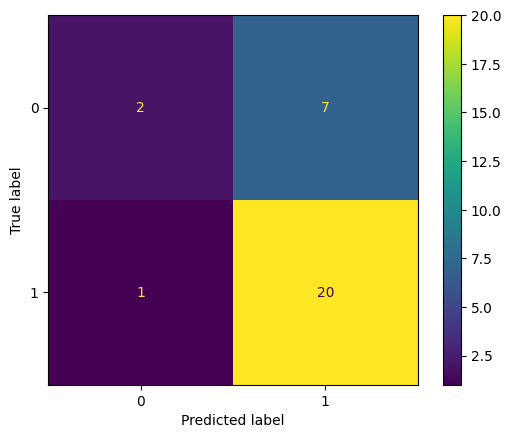

In [138]:
cm = confusion_matrix(ytest4, y4_pred)
cmd = ConfusionMatrixDisplay(cm) #display_labels = label_encoder.classes_)
cmd.plot()

In [139]:
22/30

0.7333333333333333